<a href="https://colab.research.google.com/github/samimhossainmondal6003-dotcom/AI_ML_LAB/blob/main/problem3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Route exists from Kolkata to Asansol

Connected Components:
Component 1 : ['Kolkata', 'Durgapur', 'Asansol', 'Bardhaman', 'Siliguri']
Component 2 : ['Delhi', 'Jaipur']


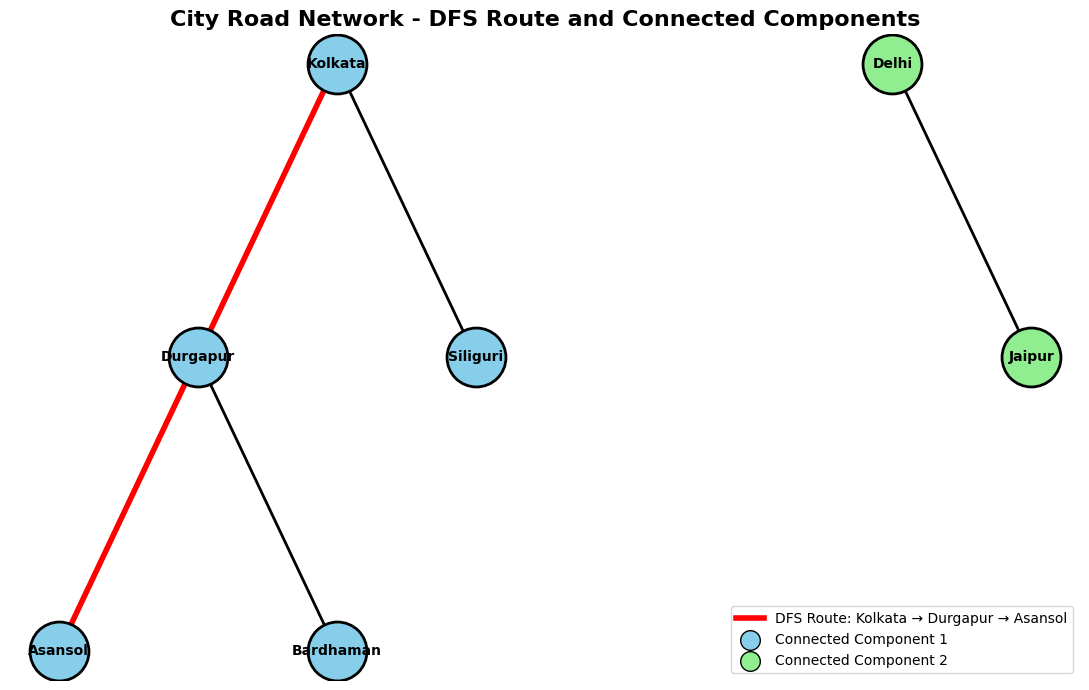

In [1]:
import matplotlib.pyplot as plt

# --------------------------------------------------
# Problem 3: Checking Routes Between Cities Using DFS
# --------------------------------------------------

# Graph represented using an adjacency list
graph = {
    "Kolkata": ["Durgapur", "Siliguri"],
    "Durgapur": ["Kolkata", "Asansol", "Bardhaman"],
    "Siliguri": ["Kolkata"],
    "Asansol": ["Durgapur"],
    "Bardhaman": ["Durgapur"],
    "Delhi": ["Jaipur"],
    "Jaipur": ["Delhi"]
}


# --------------------------------------------------
# Function to check whether a route exists
# --------------------------------------------------

def route_exists(graph, start, destination):
    visited = set()

    def dfs(city):
        if city == destination:
            return True

        visited.add(city)

        for neighbour in graph[city]:
            if neighbour not in visited:
                if dfs(neighbour):
                    return True

        return False

    return dfs(start)


# --------------------------------------------------
# Function to find connected components
# --------------------------------------------------

def find_connected_components(graph):
    visited = set()
    components = []

    def dfs(city, component):
        visited.add(city)
        component.append(city)

        for neighbour in graph[city]:
            if neighbour not in visited:
                dfs(neighbour, component)

    for city in graph:
        if city not in visited:
            component = []
            dfs(city, component)
            components.append(component)

    return components


# --------------------------------------------------
# Check route between two cities
# --------------------------------------------------

start_city = "Kolkata"
destination_city = "Asansol"

if route_exists(graph, start_city, destination_city):
    print("Route exists from", start_city, "to", destination_city)
else:
    print("No route exists from", start_city, "to", destination_city)


# --------------------------------------------------
# Find connected components
# --------------------------------------------------

components = find_connected_components(graph)

print("\nConnected Components:")

for i, component in enumerate(components, 1):
    print("Component", i, ":", component)


# --------------------------------------------------
# Matplotlib Visualization
# --------------------------------------------------

# Position of each city on the graph
positions = {
    "Kolkata": (2, 4),
    "Durgapur": (1, 3),
    "Siliguri": (3, 3),
    "Asansol": (0, 2),
    "Bardhaman": (2, 2),
    "Delhi": (6, 4),
    "Jaipur": (7, 3)
}


plt.figure(figsize=(11, 7))


# --------------------------------------------------
# Draw roads between cities
# --------------------------------------------------

drawn_edges = set()

for city in graph:
    for neighbour in graph[city]:

        edge = tuple(sorted([city, neighbour]))

        if edge not in drawn_edges:

            x_values = [
                positions[city][0],
                positions[neighbour][0]
            ]

            y_values = [
                positions[city][1],
                positions[neighbour][1]
            ]

            plt.plot(
                x_values,
                y_values,
                color="black",
                linewidth=2,
                zorder=1
            )

            drawn_edges.add(edge)


# --------------------------------------------------
# Highlight the route Kolkata -> Asansol
# --------------------------------------------------

route = ["Kolkata", "Durgapur", "Asansol"]

for i in range(len(route) - 1):

    x_values = [
        positions[route[i]][0],
        positions[route[i + 1]][0]
    ]

    y_values = [
        positions[route[i]][1],
        positions[route[i + 1]][1]
    ]

    plt.plot(
        x_values,
        y_values,
        color="red",
        linewidth=4,
        zorder=2
    )


# --------------------------------------------------
# Draw city nodes
# --------------------------------------------------

first_component = set(components[0])

for city, (x, y) in positions.items():

    if city in first_component:
        node_color = "skyblue"
    else:
        node_color = "lightgreen"

    plt.scatter(
        x,
        y,
        s=1800,
        color=node_color,
        edgecolors="black",
        linewidth=2,
        zorder=3
    )

    plt.text(
        x,
        y,
        city,
        fontsize=10,
        fontweight="bold",
        ha="center",
        va="center",
        zorder=4
    )


# --------------------------------------------------
# Add title and legend
# --------------------------------------------------

plt.title(
    "City Road Network - DFS Route and Connected Components",
    fontsize=16,
    fontweight="bold"
)

plt.plot(
    [],
    [],
    color="red",
    linewidth=4,
    label="DFS Route: Kolkata → Durgapur → Asansol"
)

plt.scatter(
    [],
    [],
    s=200,
    color="skyblue",
    edgecolors="black",
    label="Connected Component 1"
)

plt.scatter(
    [],
    [],
    s=200,
    color="lightgreen",
    edgecolors="black",
    label="Connected Component 2"
)

plt.legend(loc="lower right")

plt.axis("off")
plt.tight_layout()

plt.show()